In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-perfirmance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-perfirmance' dataset.
Path to dataset files: /kaggle/input/student-perfirmance


In [13]:
csv_path = os.path.join(path, "StudentPerformanceFactors.csv")

df = pd.read_csv(csv_path)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [15]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [16]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


**Missing values were filled with "Unknown" to preserve data and represent missing information explicitly, especially for categorical variables.**

In [18]:
df.fillna("Unknown", inplace=True)

In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')


In [22]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f"\nColumn: {col}")
    print(f"Q1 = {Q1}")
    print(f"Q3 = {Q3}")
    print(f"IQR = {IQR}")
    print(f"Lower Bound = {lower}")
    print(f"Upper Bound = {upper}")


Column: Hours_Studied
Q1 = 16.0
Q3 = 24.0
IQR = 8.0
Lower Bound = 4.0
Upper Bound = 36.0

Column: Attendance
Q1 = 70.0
Q3 = 90.0
IQR = 20.0
Lower Bound = 40.0
Upper Bound = 120.0

Column: Sleep_Hours
Q1 = 6.0
Q3 = 8.0
IQR = 2.0
Lower Bound = 3.0
Upper Bound = 11.0

Column: Previous_Scores
Q1 = 63.0
Q3 = 87.75
IQR = 24.75
Lower Bound = 25.875
Upper Bound = 124.875

Column: Tutoring_Sessions
Q1 = 1.0
Q3 = 2.0
IQR = 1.0
Lower Bound = -0.5
Upper Bound = 3.5

Column: Physical_Activity
Q1 = 2.0
Q3 = 4.0
IQR = 2.0
Lower Bound = -1.0
Upper Bound = 7.0

Column: Exam_Score
Q1 = 65.0
Q3 = 69.0
IQR = 4.0
Lower Bound = 59.0
Upper Bound = 75.0


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler.fit_transform(df[num_cols])

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[num_cols] = scaler.fit_transform(df[num_cols])

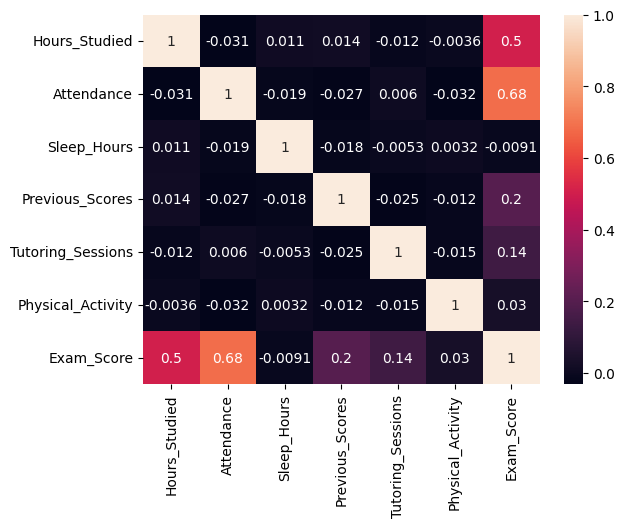

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()

**PCA was applied because some numerical features showed correlation, and it helps reduce dimensionality while preserving important information.**

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_zscore[num_cols])

# 1. Transformed data (new features)
print("PCA Transformed Data:\n", pca_data)

# 2. Explained variance (how much info each component keeps)
print("\nExplained Variance:", pca.explained_variance_)

# 3. Explained variance ratio (percentage)
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

# 4. Components (feature importance in each PC)
print("\nPCA Components:\n", pca.components_)

PCA Transformed Data:
 [[ 0.23221999  0.55116423]
 [-2.25577953  0.10849784]
 [ 2.92909555  0.14720701]
 ...
 [ 0.79995282 -1.71796506]
 [ 0.08545832 -1.11910911]
 [-1.59215349  1.57050509]]

Explained Variance: [1.86389399 1.06256009]

Explained Variance Ratio: [0.26622659 0.15176923]

PCA Components:
 [[ 0.39534118  0.54645343 -0.0181673   0.15096313  0.11064907 -0.00085731
   0.71395387]
 [ 0.57884508 -0.48817571  0.16121892  0.45642208 -0.36922624  0.23590312
   0.01821797]]
